# Etapa 2 del proyecto: Hacia una medicina preventiva en hipertensión arterial

La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial[1]. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. **La finalidad es doble**: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas.


Con el contexto del problema podemos evidenciar que debemos:
- **desarrollar modelos predictivos**
- **que permitan estimar**
- **el riesgo de hipertensión en pacientes**

Para:
- **facilitar la identificación temprana**
- **dentificar los factores clave que influyen en el desarrollo de la enfermedad**


In [1]:
#Importacíón de librerias:

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV , StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from importlib.metadata import version
from ydata_profiling import ProfileReport


from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de ydata_profiling: {version('ydata_profiling')}")

Versión de Pandas: 2.3.3
Versión de Matplotlib: 3.10.0
Versión de Scikit-learn: 1.8.0
Versión de Numpy: 2.1.3
Versión de ydata_profiling: 4.18.0


# **1. Exploración y perfilamiento de los datos**

In [2]:
ruta = "./Data/Datos_hipertension.csv"
data_raw = pd.read_csv(ruta, sep=";" , encoding="latin1")

Al intentar cargar los datos generó un error ya que contiene valores con tilde como por ejemmplo las variables "Medicación" es por eso que se usa el encoding "Latin1"

In [3]:
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


In [4]:
data = data_raw.copy()

In [5]:
data.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## Revisión de  datos nulos y duplicados:

In [6]:
data.isna().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   object 
 7   Historia_Familiar   1990 non-null   object 
 8   Actividad_Fisica    1990 non-null   object 
 9   Fumador             1990 non-null   object 
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   object 
 12  Hipertension        1990 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 202.2+ KB


<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Al ejecutar el análisis se observa que el dataset no contiene valores faltantes. No hay varoles nulos entonces no se requiere imputación. Aunque si se colocará un Imputer para los pipelines, por si en datos futuros o en un escenario de producción se diera el caso.

La decisión del parametro del SimpleImputer a utlizar se tomará mas adelante, según los análisis de los tipo de variables.

</div>

In [8]:
data.duplicated().sum()

np.int64(4)

In [9]:
data = data.drop_duplicates()

In [10]:
data.shape

(1986, 13)

<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Se encontraron registros duplicados que deben ser tratados antes de entrenar el modelo.
Se eliminan de una vez.

</div>

## División de los datos en Train y Test:

Realizo de una vez la divisón para no ver nada del test y realizar posteriormente un análisis de los datos solo con train.
Uso `stratify` para que me distribuya uniformemente los datos con respecto a mi variable target `Hipertension`

In [11]:
train, test = train_test_split(data, test_size=0.2, random_state=77, stratify=data['Hipertension'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

In [12]:
X_train = train.drop(['Hipertension'], axis=1)
y_train = train['Hipertension']

X_test = test.drop(['Hipertension'],axis=1)
y_test = test['Hipertension']

# Codificar target 
y_train = y_train.map({'Si': 1, 'No': 0})
y_test = y_test.map({'Si': 1, 'No': 0})

In [13]:
X_train

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
0,31,6.9,2,153.4,6.0,27.0,BloqueadorBeta,Si,Moderada,No,75.4,No
1,40,11.6,10,199.4,5.7,24.8,InhibidorACE,No,Moderada,No,104.2,No
2,29,9.8,9,192.7,7.9,27.6,Ninguna,No,Alta,Si,104.8,No
3,18,11.3,3,192.1,7.5,32.4,Otro,Si,Alta,No,100.3,Si
4,39,4.6,9,183.9,4.4,26.6,Ninguna,No,Baja,No,100.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...
1583,27,7.5,9,156.4,6.6,26.0,BloqueadorBeta,Si,Baja,No,100.1,No
1584,22,5.1,1,201.7,5.2,24.7,Ninguna,No,Moderada,No,70.8,Si
1585,64,8.2,9,203.3,5.1,23.3,Ninguna,No,Baja,No,88.7,No
1586,49,4.9,3,207.9,5.5,24.1,InhibidorACE,No,Baja,Si,100.2,No


In [14]:
y_train

0       0
1       0
2       0
3       1
4       0
       ..
1583    0
1584    0
1585    0
1586    1
1587    0
Name: Hipertension, Length: 1588, dtype: int64

## **Perfilamiento de los datos**:

### Verificación de valores unicos, tipos de datos, tipo de variable:

In [15]:
resumen = pd.DataFrame({
    'tipo_dtype': train.dtypes,
    'num_unicos': train.nunique(),
    'ejemplo_valores': [train[col].dropna().unique()[:6].tolist() for col in train.columns],
    'min': train.select_dtypes(include=['int64', 'float64']).min().reindex(train.columns),
    'max': train.select_dtypes(include=['int64', 'float64']).max().reindex(train.columns),
    'Tipo_variable': [
        'Binaria' if train[col].nunique() == 2
        else 'Categórica' if train[col].nunique() <= 10
        else 'Numérica '
        for col in train.columns
    ]
})
resumen

,tipo_dtype,num_unicos,ejemplo_valores,min,max,Tipo_variable
Edad,int64,67,"[31, 40, 29, 18, 39, 27]",18.0,84.0,Numérica
Ingesta_Sal,float64,118,"[6.9, 11.6, 9.8, 11.3, 4.6, 9.0]",2.5,16.4,Numérica
Nivel_Stres,int64,11,"[2, 10, 9, 3, 0, 6]",0.0,10.0,Numérica
Colesterol,float64,913,"[153.4, 199.4, 192.7, 192.1, 183.9, 205.3]",121.2,2360.0,Numérica
Duración_Sueño,float64,86,"[6.0, 5.7, 7.9, 7.5, 4.4, 7.1]",1.5,11.0,Numérica
BMI,float64,230,"[27.0, 24.8, 27.6, 32.4, 26.6, 30.7]",11.9,41.9,Numérica
Medicación,object,5,"[BloqueadorBeta, InhibidorACE, Ninguna, Otro, ...",NaN,NaN,Categórica
Historia_Familiar,object,2,"[Si, No]",NaN,NaN,Binaria
Actividad_Fisica,object,3,"[Moderada, Alta, Baja]",NaN,NaN,Categórica
Fumador,object,2,"[No, Si]",NaN,NaN,Binaria


Al realizar un análisis de los datos, contrastando con el diccionario se puede ver concluir que:

- Todas las 6 variables númericas `(Edad, Nivel_Stres, BMI, Duración_sueño, Colesterol, Glucosa)` son acordes al diccionario.
- En el resultado del dataframe se observa una **septima** variable númerica, la cual corresponde a `ingesta de sal`. Esta variable es inconsistente con nuestro diccionario ya que debería ser `Categorica ordinal` y el tipo de datos deberìa ser `bajo,moderado,alto`, además no tenemos una manera de saber cuales son los rangos de valores núericos para cada categoria, por lo que para este caso se toma la decisión de eliminarla y no tomarla encuenta para el ejercicio, ademàs se consultò con el experto(foro) y se tomò la decisiòn de no utilizarla.
- La unica variable `Categorica Ordinal` sería entonces `actividad física` ya que tiene un orden de peso en sus categorias y se realizará un tratamiento de datos para convertirla a la forma **[0,1,2]**
- La única variable `Categórica Nominal` sería entonces `Medicación`
- La variable target `Hipertension` es correcta, ya que se observa que  es categorica y binaria(Solo tiene dos posible valores, si y no)
- También se detecta un valor max de `colesterol` mucho mayor que con respecto al conjunto de **ejemplo unicos**, revisará a continuación la revisión de Outliners.
- Las variables  `fumandor`, `Enfernedad_corazòn`, `Historia familiar` tiene datos correctós según lo esperado al revisar el diccionario.


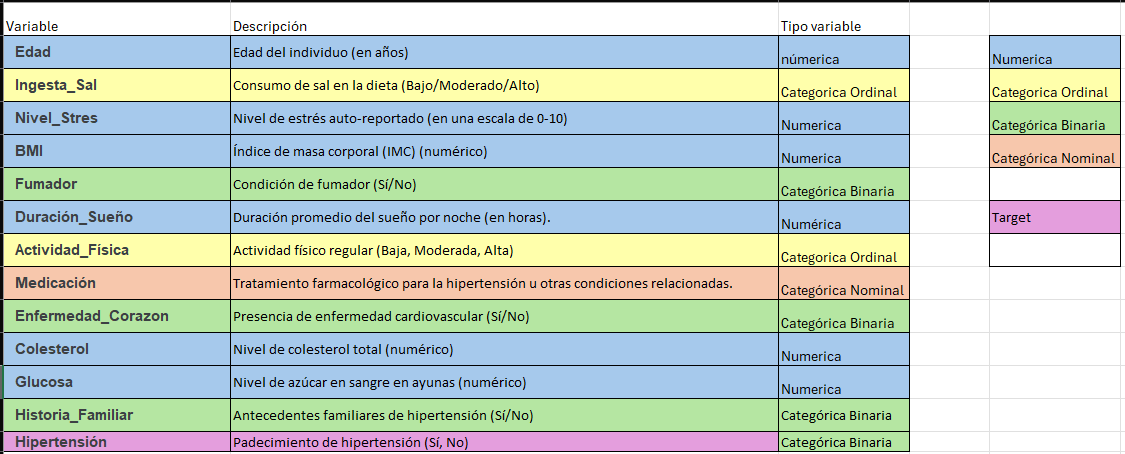

## Detección de Outliners:

In [16]:
numericas = ['Edad','Nivel_Stres','BMI','Duración_Sueño','Colesterol','Glucosa']
cat_Ordinal = ['Actividad_Fisica']
cat_binarias = ['Fumador','Enfermedad_Corazon','Historia_Familiar']
cat_nominal = ['Medicación']


In [17]:
print(X_train.describe())
print(X_train.shape)
print(y_train.shape)

              Edad  Ingesta_Sal  Nivel_Stres   Colesterol  Duración_Sueño  \
count  1588.000000  1588.000000  1588.000000  1588.000000     1588.000000   
mean     50.200882     8.529975     5.040302   210.189295        6.473111   
std      19.266854     1.976410     3.143834    83.219154        1.528070   
min      18.000000     2.500000     0.000000   121.200000        1.500000   
25%      34.000000     7.200000     2.000000   181.275000        5.475000   
50%      50.000000     8.500000     5.000000   203.900000        6.500000   
75%      67.000000     9.900000     8.000000   231.800000        7.500000   
max      84.000000    16.400000    10.000000  2360.000000       11.000000   

               BMI      Glucosa  
count  1588.000000  1588.000000  
mean     25.975441   105.194962  
std       4.553397    22.420448  
min      11.900000    70.000000  
25%      22.900000    89.075000  
50%      25.900000   101.900000  
75%      29.200000   119.500000  
max      41.900000   196.100000  


Con describe se observam ciertos outliners, sobre todo con respecto a `colesterol` por el valor max de `2360`.

Se corrobora también que todos los datos están completos con un total de `1588 registros ` para nuestro conjunto train

En los siguientes Diagramas de Caja y Bigotes utilizaré el conjunto train y no ver nunca el conjunto test. Aquí revisaré outliners para la toma de decisiones sobre `imputación`,`eliminación`,`estandarización` según sea el análisis de los outliners. Además de que justamente en este punto ya he realizado la división de los datos en train y test.

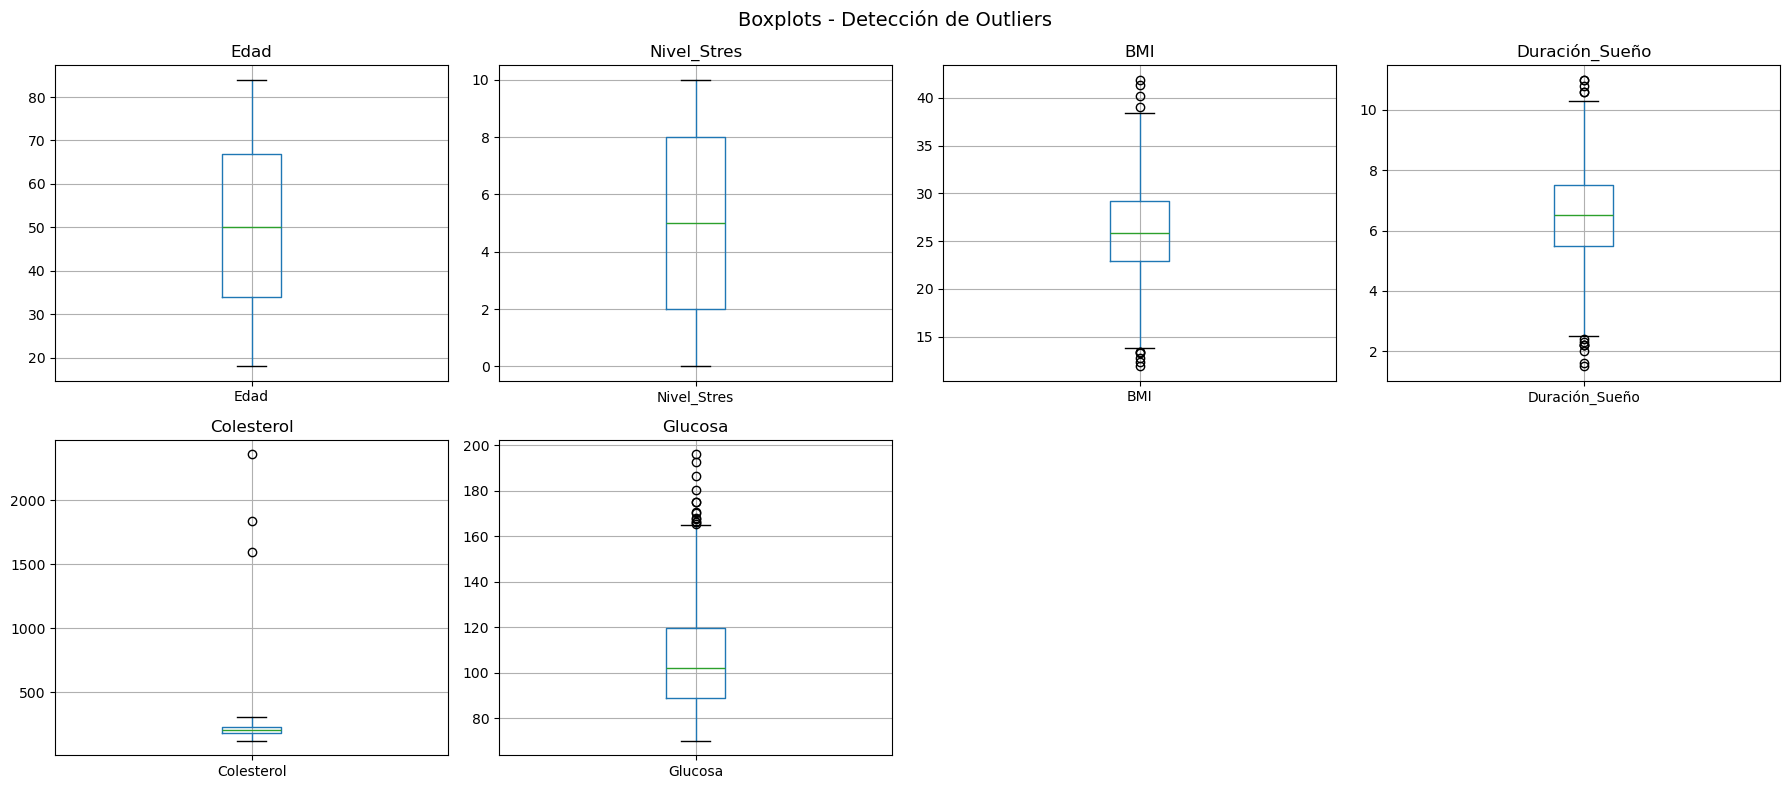

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numericas):
    ax = axes[i // 4, i % 4]
    train.boxplot(column=col, ax=ax)
    ax.set_title(col)

for j in range(len(numericas), axes.size):
    axes.flat[j].axis('off')
plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Como se puede observar, <b>BIM, duración sueño, colesterol y Glucosa</b>> tiene valores outliners
- Además de que se observan los mayores valores de outliners en <b>colesterol</b> con respecto a las diferencias que hay en las otras variables.

</div>

Aqui voy a mostrar explicitamente cual son esos valores outliners,  para entender la naturaleza de los datos para tomar una decisión:

In [19]:
# Ojo aqui tambíen usaré el conjunto train para no ver nada de test.

for col in numericas:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    if not outliers.empty:
        print(f"\n--- {col} ---")
        print(f"Rango válido: [{lower:.2f}, {upper:.2f}]")
        print(f"Outliers encontrados: {len(outliers)}")
        print(outliers[col].values)


--- BMI ---
Rango válido: [13.45, 38.65]
Outliers encontrados: 10
[12.4 40.2 13.4 13.4 39.  41.3 41.9 12.8 11.9 13.3]

--- Duración_Sueño ---
Rango válido: [2.44, 10.54]
Outliers encontrados: 13
[ 1.5  2.4 11.  10.6  2.2 11.  10.8  2.2  2.3  2.   2.2 10.6  1.6]

--- Colesterol ---
Rango válido: [105.49, 307.59]
Outliers encontrados: 3
[1597. 1835. 2360.]

--- Glucosa ---
Rango válido: [43.44, 165.14]
Outliers encontrados: 13
[166.2 175.3 192.7 175.3 165.3 167.4 186.7 170.5 166.4 168.1 196.1 170.3
 180.5]


<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Con lo anterior podemos observar que los outliners de <b>Colesterol </b> parecen ser datos mal digitados en la recolección de los mismos ya que clinicamente no es posible tener valores de <b>2360.  1597.  1835</b> 

Según las guías clínicas de la AHA/ACC 2018, el colesterol total normal es inferior a 200 mg/dL y se considera alto a partir de 240 mg/dL. Incluso en los casos más extremos documentados médicamente, como la hipercolesterolemia familiar homocigota (NCBI Bookshelf, NIH), los niveles de LDL rara vez superan los 500 mg/dL o 700 del colesterol total. Se tomará la decisión de eliminar estos 3 registros con colesterol total mayor a 700
Rerefencias consultadas: https://www.healthline.com/health/high-cholesterol/levels-by-age y https://pubmed.ncbi.nlm.nih.gov/2180270/

El resto de outliners sobre las otras variables son posibles y no son tan extremos como un BMI de 41.9 es obesidad severa pero real, una glucosa de 196 es alta es un valor muy cercano a otros valores con gran cantidad de datos en nuestro dataset, y dormir 1.5 horas es extremo pero no imposible. <b> No se eliminaran ni imputaran, solo se aplicará RobustScaler para el caso de KNN para que regule mejor estos datos</b>

</div>

## Distribución de variables categoricas:

En los siguientes apartados solo usaré el train

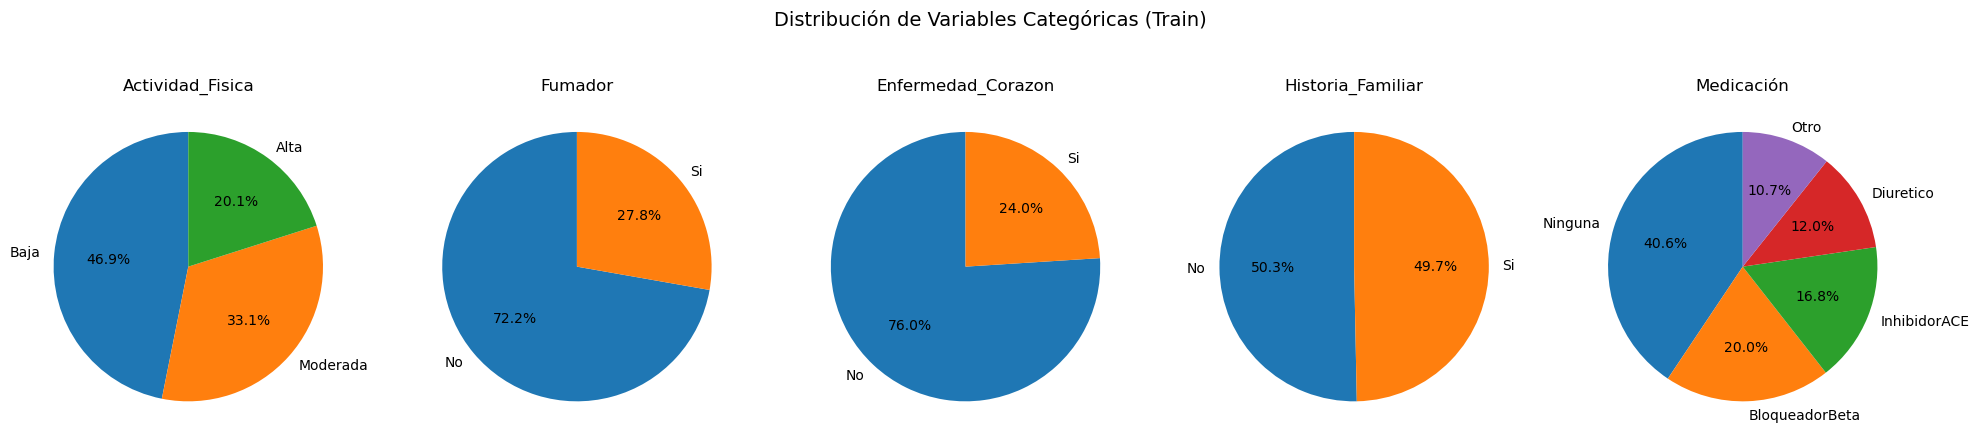

In [20]:
#cat_Ordinal = ['Actividad_Fisica']
#cat_binarias = ['Fumador','Enfermedad_Corazon','Historia_Familiar']
#cat_nominal = ['Medicación']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(cat_Ordinal + cat_binarias + cat_nominal):
    counts = X_train[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col)

plt.suptitle('Distribución de Variables Categóricas (Train)', fontsize=14)
plt.tight_layout()
plt.show()

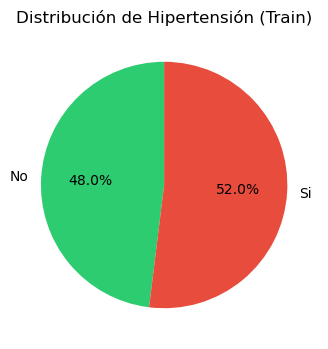

In [21]:
labels = {0: 'No', 1: 'Si'} #aqui coloco un label para cambiar los valores 0 y 1 a su valor semantico real ya que en la división hice de una vez la codificación.
fig, ax = plt.subplots(figsize=(5, 4))
counts = y_train.value_counts().sort_index()
ax.pie(counts, labels=[labels[i] for i in counts.index], autopct='%1.1f%%', 
       colors=['#2ecc71', '#e74c3c'], startangle=90)
ax.set_title('Distribución de Hipertensión (Train)')
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Se analizan las distribuciónes de todas las variables categóricas y Target para concluir que:
- Aunque las variables Fumador y enfermedad son las variablas mas desbalanceadas, sus respectivas distribuciones son representativas del problema y no requieren de algo ajuste o transformación
- Medicación tambíen tiene diversas proporciones de los datos, pero ninguna de ellas son lo suficientemente baja como por ejemplo la categoria <b>Otros</b> como para que amerite alguna imputación o transformación.
- Tan Historial familiar y como Hipertención(target) están casi perfectamente distribuidas 50/50 lo cual es bueno para el entranmiento ya que no se tendrán sesgos por este lado.

</div>

## Distribución de variables numéricas:

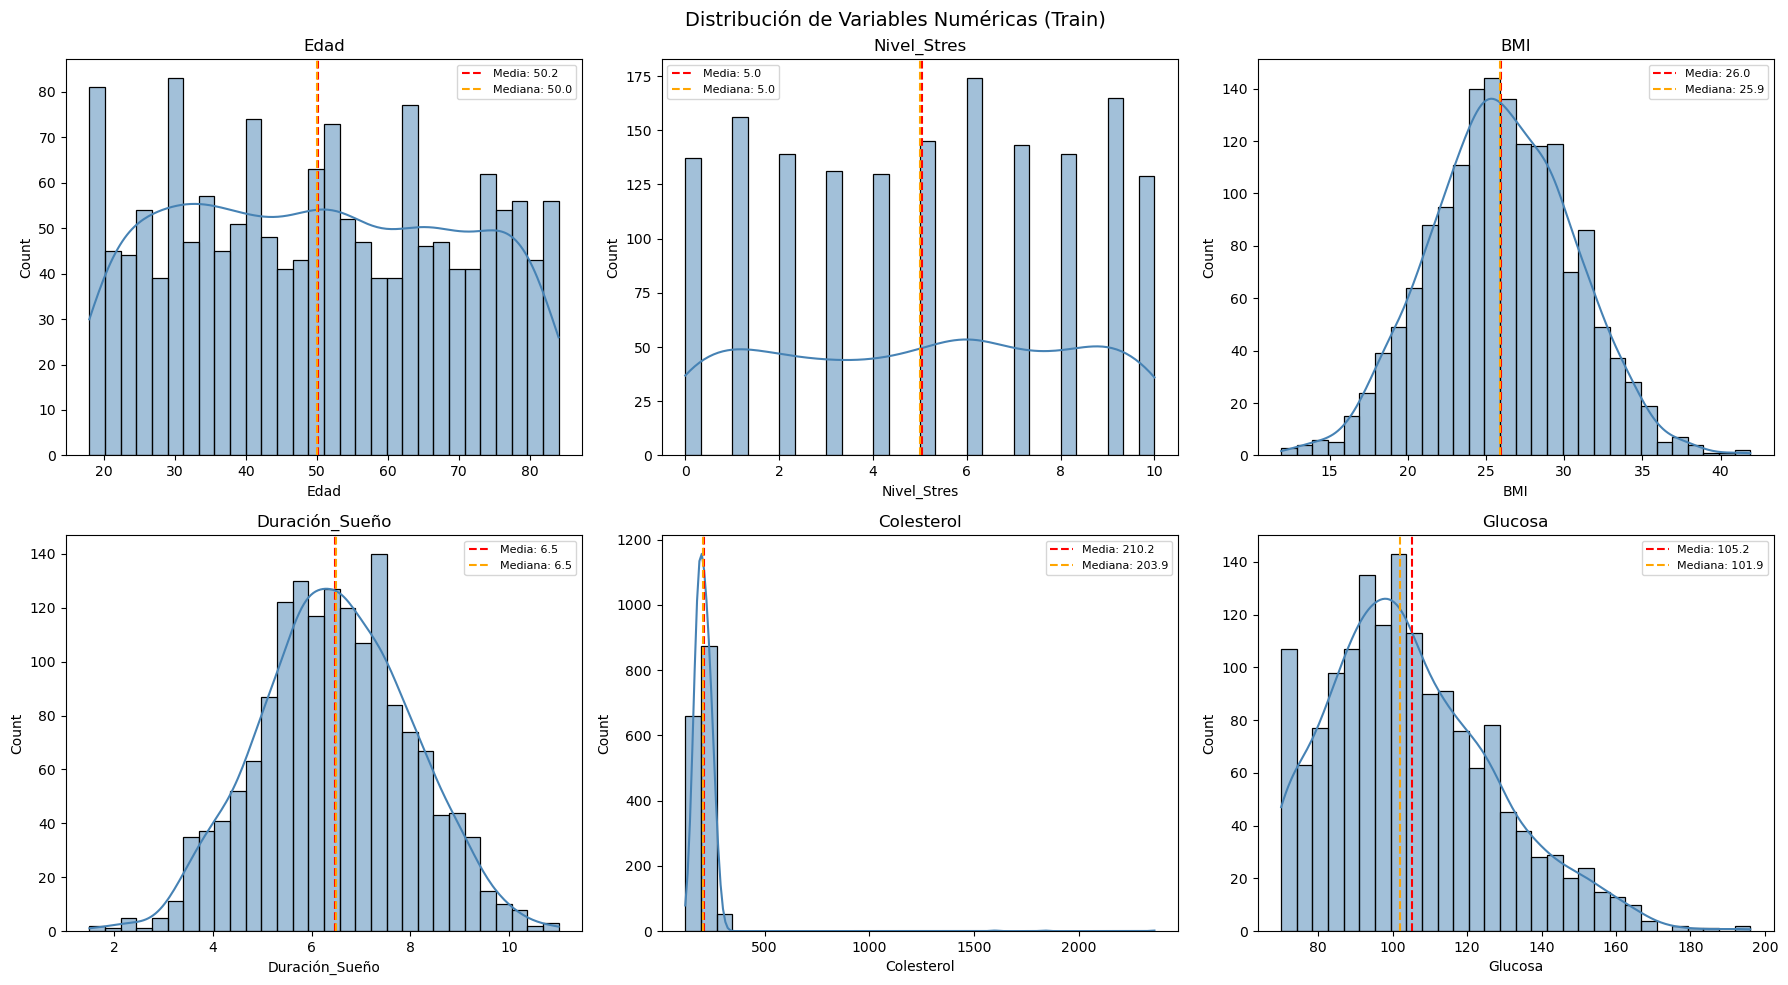

In [22]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(numericas):
    ax = axes[i // 3, i % 3]
    sns.histplot(X_train[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(X_train[col].mean(), color='red', linestyle='--', label=f'Media: {X_train[col].mean():.1f}')
    ax.axvline(X_train[col].median(), color='orange', linestyle='--', label=f'Mediana: {X_train[col].median():.1f}')
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
- Edad ->  Distribución aproximadamente uniforme, con varios picos, pero en general tiene muy buena simetría debido a la media de 50.6 y mediana 50
- No nivel_stres -> Muy buena distribución, muy uniforme y simetría. Esto se aprecia fácilmente con la curva de densidad que se ve sobre la gráfica.
- BMI -> Tiene una distribución gausiana (campana de Gauss) , una distribución normal.
- Duración del sueño -> Tambíen tiene una distribución normal.
- Colesterol -> <b>Claramente la distribución se ve afectada por los outliners. Se sigue afirmando que se realizará una eliminación de estos datos ya que representan menos del 1% del total de los datos y además son valores clínicamente imposibles según la literatura médica consultada (AHA/ACC, NCBI/NIH)</b>
- Glucosa -> Tiene una distribución normal aunque un poco sesgada hacia datos con glucosa Altos, <b>se sigue afirmando que se tomará la decisión de aplicar RobustScaler para que el modelo KNN se comporte mejor a datos extremos</b>

</div>

## Matriz de correlación

Aqui realizo un análisis de las correlaciones entre las variables numéricas unicamente:

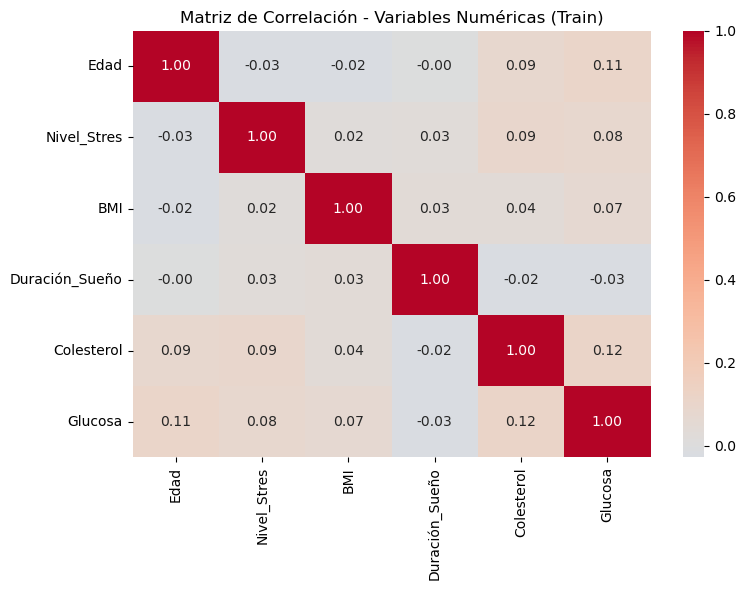

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = X_train[numericas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Matriz de Correlación - Variables Numéricas (Train)')
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Se puede concluir que al analizar la matriz de correlación se evidencia que las correlaciones entre las variables están por debajo del umbral 0.8, incluso valorer cercanos a 0 por ende no es necesario eliminar alguna variable.

</div>

## Numéricas vs Target

Estas gráficas nos ayudan a ver si los pacientes hipertensos tienen valores diferentes a los no hipertensos en cada variable:

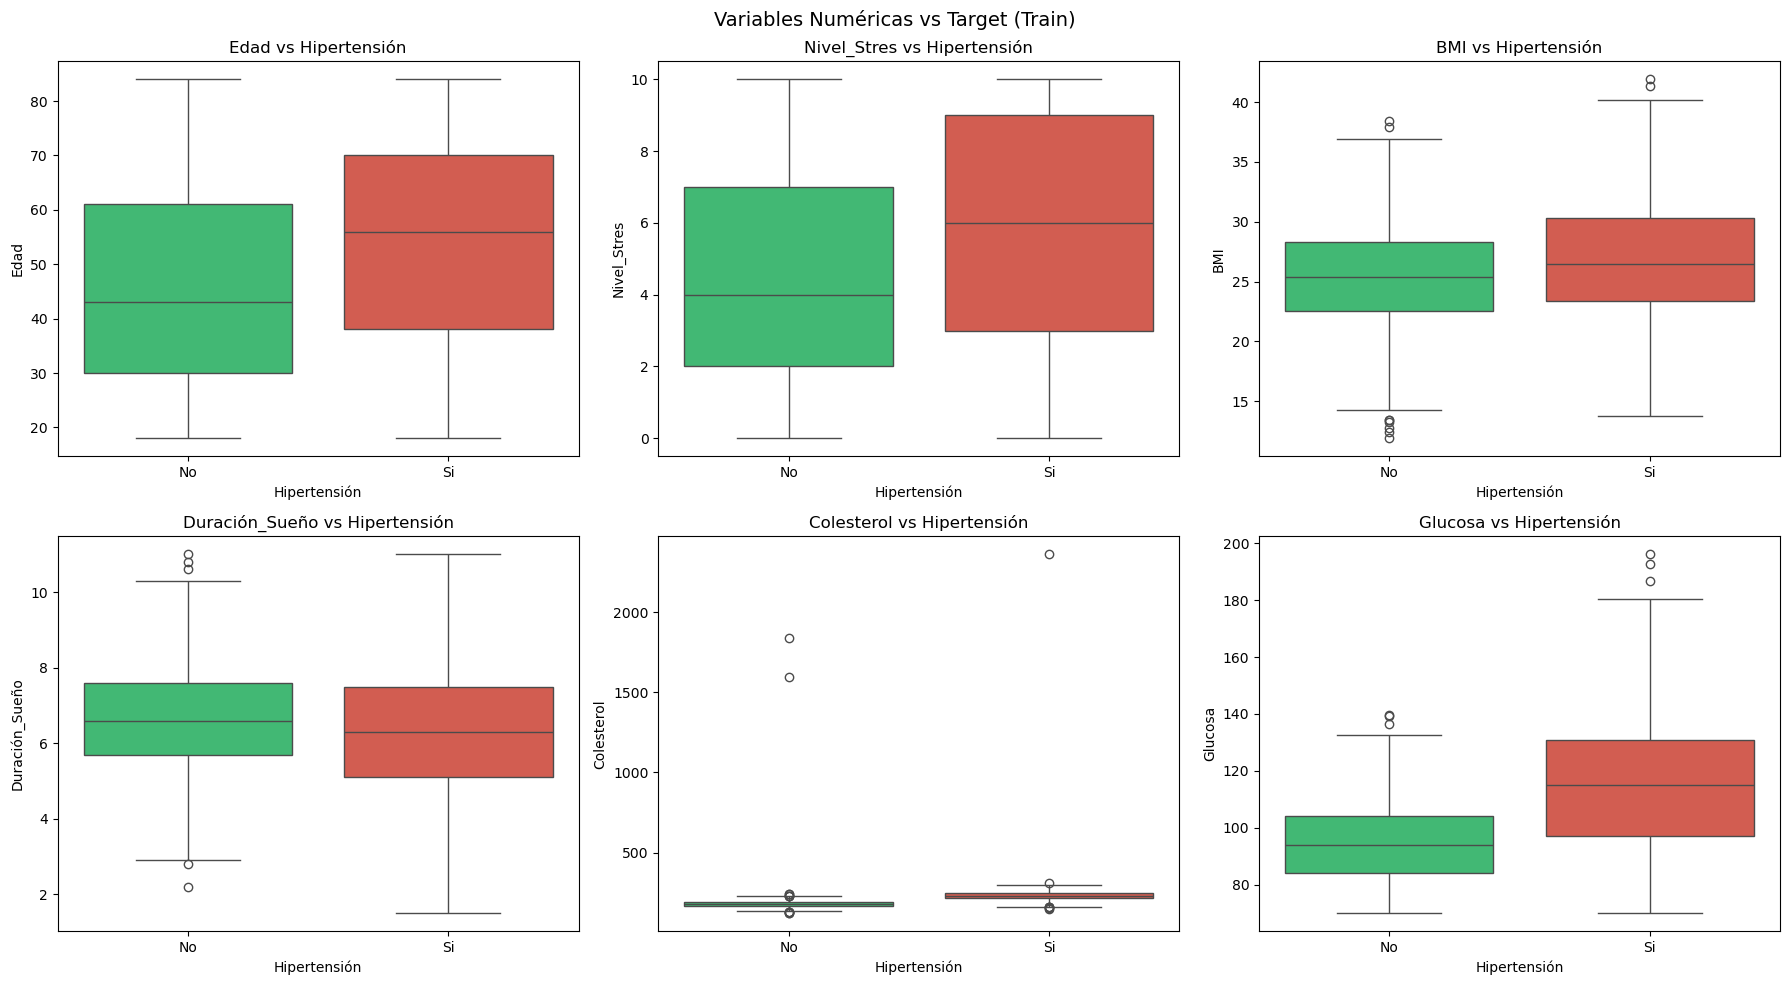

In [24]:
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(numericas):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x=y_train, y=X_train[col], ax=ax, hue=y_train, 
                palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)
    ax.set_title(f'{col} vs Hipertensión')
    ax.set_xlabel('Hipertensión')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Si'])

plt.suptitle('Variables Numéricas vs Target (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Con estas gráficas podemos saber cual son las variables que muy posiblemente sean las más importante para los modelos a la hora de predecir si una persona puede o no tener hipertención. Al observarlas podemos evidenciar que:
- Edad -> Entre más años tenga una persona más probable es que tenga hipertención. Parece ser un predictor importante.
- <b>Nivel_stres -> Entre mayor sea el nivel de stres por encima de aproximadamente 6 entonces es más probable que sufrir hipertención</b>
- BMI -> Parece ser que el indice de masa corporal de la persona por si solo no es tan discriminante para identificar una posible razón de hipertención
- Duración del sueño -> Observamos lo mimo que el BMI, no parece ser un factor relevante.
- <b>Colesterol -> Nuevamente los outliners extremos o anómalos no nos permiten ver como realmente se comportan estos datos con el target, aunque se podría alcanzar a visualizar una leve diferencia en las cajas mostrando que posiblemente un alto nivel de colesterol puede ser un factor de un indicio de hipertención.</b>
- <b>Glucosa -> Vemos que valores por encima de aproximadamente 110 resulta en un factor positivo para hipertención. Parece ser una variabla muy importe para la predicción.</b>
</div>

## Categóricas vs Target

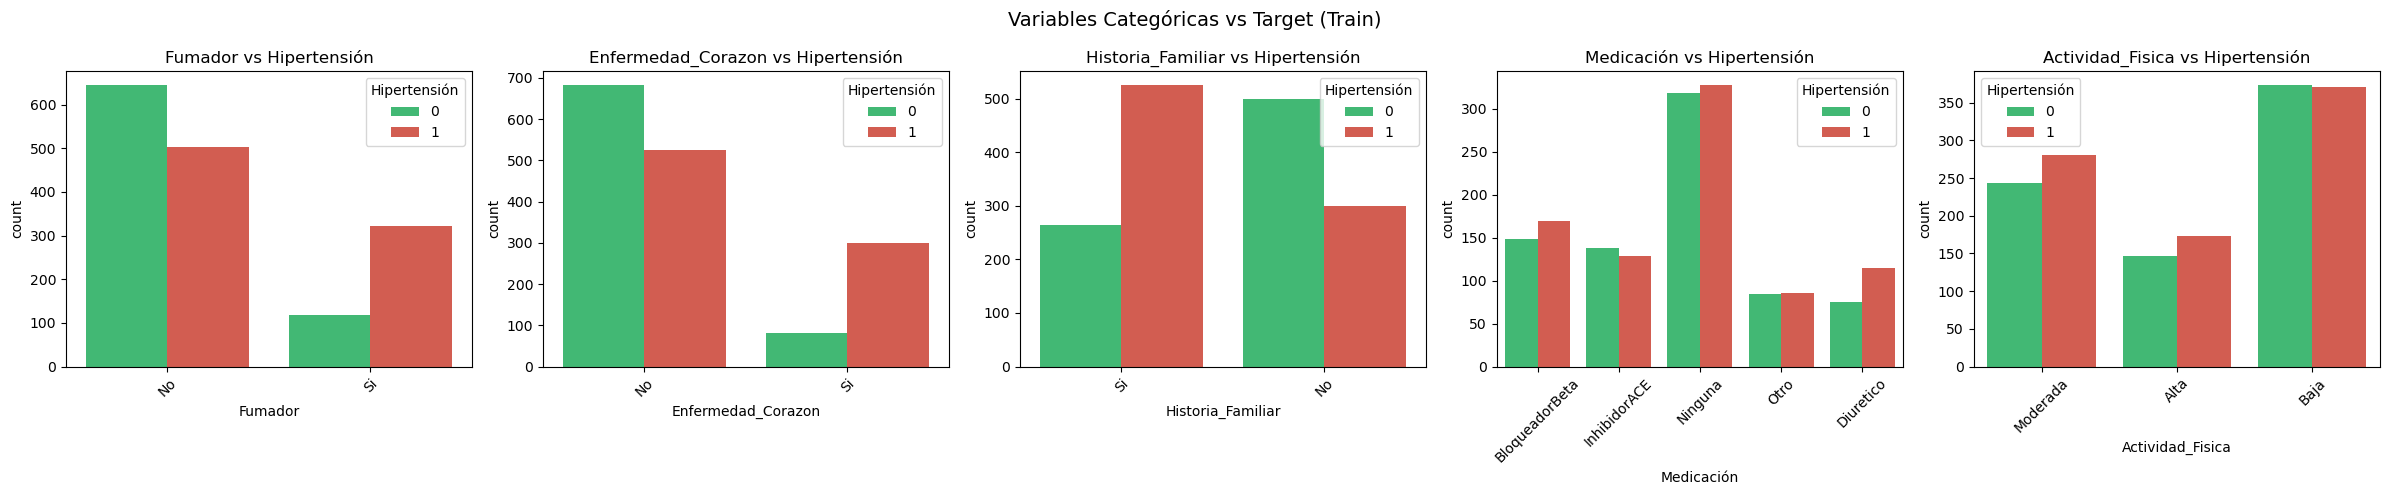

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

train_temp = X_train.copy()
train_temp['Hipertension'] = y_train.values

for i, col in enumerate(cat_binarias + cat_nominal + cat_Ordinal):
    sns.countplot(x=col, hue='Hipertension', data=train_temp, ax=axes[i],
                  palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Hipertensión')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Hipertensión')

plt.suptitle('Variables Categóricas vs Target (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Con estas gráficas podemos saber cual son las variables categóricas que muy posiblemente sean las más importante para los modelos a la hora de predecir si una persona puede o sufrir hipertención.
- Fumador -> Según la gráfica podemos observar <b>claramente que existe una relación de peso si la persona fuma o no</b> para predecir hipertención
- Enfermedad del corazón -> Prácticamente el mismo patrón proporcional que Fumador, parece ser <b>muy importante a la hora de predecir hipertención</b>.
- Historial familiar -> También parece ser un <b>factor muy importante</b> para predecir la hipertención.
- Medicación -> Se observa una proporción uniforme entre las 5 categorias, aunquen podríamos estimar que para el modelo final puede ser mas importante si la persona tiene <b>medicación Diuretico, mas sin embargo es posible que Medicación no sea una buena predictora</b>
- Actividad física -> Se observa un patrón muy uniforme, no hay diferencias notables en las proporciones, no parece ser una variable tan importante para estimar la hipertención.
</div>

# Limpieza y preparación de los datos:

A continuación se creará una función de limpienza y pipeline para esto proceso, sustentado sobre las conclusiones del EDA. Listo a continuación un resumen de las conclusiones:
- Eliminar la variable Ingesta de sal
- Eliminar datos anómalos clinicamente improbables de Colesterol
- Incluir en el pipeline un imputador para datos futuros que vengan vacios. Aunque en este caso no teniamos este escenario puede que en producción suceda entonces me aseguro de esto de una vez.



Crearé una función `limpiar_datos` para la Etapa 1 de Pipeline de limpieza y preparación de datos, para poder reutilizarla para cualquier escenario, sobre todo para el conjunto test y tamìen si se llega a producción.
Esta función lo que permite es eliminar la variabla Ingesta_Sal se incluye dentro de conjunto de variables y también realiza la limpieza de los datos anómalos o clinicamente imposibles de la variable Colesterol, además al final me mostrará los registros eliminados si existieran validando en `if n_eliminados > 0:`

In [26]:
def limpiar_datos(X, y=None):
    """
    Aplica reglas de negocio clínicas para limpiar datos.
    Se creó esta función ya que más adelante se tiene que hacer el mismo proceso para Test.
    Y tambíen para datos futuros.
    
    Reglas aplicadas:
    1. Eliminar columna Ingesta_Sal (inconsistente con diccionario médico)
    2. Eliminar registros con Colesterol > 700 
    
    Parámetros:
    X: DataFrame con variables descriptoras
    y: Datos de variable target, para sincronizar las filas eliminadas.
    
    Retorna:
    X_limpio, y_limpio (si se pasó y)
    X_limpio 
    """
    X_clean = X.copy()
    
    if 'Ingesta_Sal' in X_clean.columns:
        X_clean = X_clean.drop(columns=['Ingesta_Sal'])
    
    mask = X_clean['Colesterol'] <= 700
    n_eliminados = (~mask).sum()
    if n_eliminados > 0:
        print(f"{n_eliminados} registros eliminados (Colesterol > 700)")
    
    X_clean = X_clean[mask]
    
    if y is not None:
        y_clean = y[mask]
        return X_clean, y_clean
    
    return X_clean

# **2. Construcción del pipeline de limpieza y preparación de los datos**

**Justificación de las decisiones basadas en el EDA:**

| Decisión | Justificación |
|---|---|
| Eliminar Ingesta_Sal | Inconsistente con el diccionario del experto médico. Consultado con el experto. |
| Eliminar Colesterol > 700 | Valores clínicamente imposibles según guías AHA/ACC. Solo 3 registros (menos del 1% del dataset) |
| SimpleImputer (median) para numéricas | Prevención para datos futuros. Se usa mediana por coherencia con RobustScaler ya tambìen usa la mediana |
| SimpleImputer (most_frequent) para categóricas | Prevención para datos futuros. Se imputa con la categoría más frecuente |
| RobustScaler para numéricas | Se observaron outliers estadísticos válidos en BMI y Glucosa durante el EDA. Obligatorio para para KNN ya que mide distancias |
| OrdinalEncoder para Actividad_Fisica | Orden natural: Baja(0) < Moderada(1) < Alta(2) |
| OneHotEncoder(drop='if_binary') | Evita multicolinealidad en binarias. Para Medicación genera 4 dummies |
| remainder='drop' | Ignora columnas no especificadas. Por si en producción llegan columnas extra. |

**Nota:** La limpieza se implementa como función separada ya que involucra 
eliminación de filas y esa operación el Pipeline de sklearn no soporta al estar 
diseñado para transformaciones a nivel de columnas. Ambas etapas son reutilizables 
para datos nuevos en producción.

In [27]:
#numericas = ['Edad','Nivel_Stres','BMI','Duración_Sueño','Colesterol','Glucosa']
#cat_Ordinal = ['Actividad_Fisica']
#cat_binarias = ['Fumador','Enfermedad_Corazon','Historia_Familiar']
#cat_nominal = ['Medicación']

#Etapa 1 Limpieza:
X_train,y_train = limpiar_datos(X_train,y_train)

#Etapa 2
#Pipeline transformaciones:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Baja', 'Moderada', 'Alta']]))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('numericas', num_pipeline, numericas),
    ('ordinales', ordinal_pipeline, cat_Ordinal),
    ('categoricas', cat_pipeline, cat_binarias + cat_nominal)
], remainder='drop')

preprocessing

3 registros eliminados (Colesterol > 700)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('ordinales', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

En el paso anterior contruí todos los pipelines por cada tipo de variables que se determinó en el EDA.

Tambíen se aplicó la función creada para realizar la limpieza de los datos. A continuación vamos a observar como se ve colesterol despues de hacer la limpieza:

Se utilizará el mismo preprocesador para ambos modelos (árbol de decisión y KNN). Aunque los árboles de decisión no requieren escalamiento (trabajan con umbrales que son invariantes al cambio de escala), aplicar RobustScaler no afecta su rendimiento. Esto permite mantener un pipeline unificado que sí beneficia a KNN, el cual requiere escalamiento obligatoriamente al calcular distancias euclidianas.

| Transformación | ¿Árbol lo necesita? | ¿KNN lo necesita? | Justificación |
|---|---|---|---|
| SimpleImputer | ✅ Sí | ✅ Sí | Ningún modelo acepta valores nulos |
| RobustScaler | ❌ No afecta | ✅ Obligatorio | KNN calcula distancias euclidianas, sin escalar las variables con rangos grandes dominarían el cálculo. El árbol trabaja con umbrales que son invariantes al cambio de escala |
| OrdinalEncoder | ✅ Sí | ✅ Sí | Sklearn requiere entrada numérica. Actividad_Fisica tiene orden natural (Baja < Moderada < Alta) |
| OneHotEncoder | ✅ Sí | ✅ Sí | Sklearn no acepta strings. Medicación no tiene orden intrínseco, se crean columnas dummy |

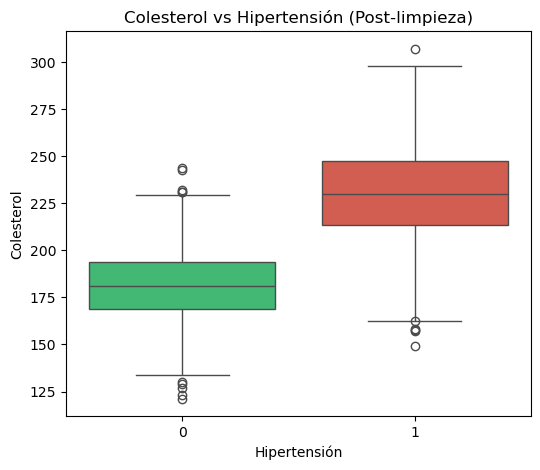

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x=y_train, y=X_train['Colesterol'], hue=y_train,
            palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
ax.set_title('Colesterol vs Hipertensión (Post-limpieza)')
ax.set_xlabel('Hipertensión')
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Ahora si pudemos generar una conclusión bastante buena ya que al elmimnar los 3 registros anómalos de colesterol podemos analizar mucho mejor sus datos.

- Se concluye que la varible `Colesterol` puede ser una de las màs representativas para el problema a la hora de predecir si una persona podría sufrir o no hipertención.
</div>

**Después de la limpieza, las que muestran mayor separación visual y quizas mejores predictoras para los modelos son:**
|Variable|Interpretación visual|
|---|---|
|Colesterol —>| separación muy clara (ahora visible despues de la limpieza)|
|Enfermedad del corazón —>| Se evicencia una clara diferencia en las proporciones, puede ser muy importante|
|Fumador —>| Tambíen una clara diferencia de proporciones de SI/NO, muy predictora|
|Edad —>| Tambíen es una buena predictora|
|Glucosa —>| separación clara|
|Nivel_Stres —>| buena separación|
|historia familiar —>| Proporciones diferencidas, también debería influir mucho|


# **3. Construcción de un modelo de árboles de decisión.**

 Utilizando la función `GridSeacrhCV`, con el siguiente espacio de búsqueda: `{'criterion':['gini', 'entropy'],` `'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}. `

 - Notese que en el GridSearchCV utilizaré la métrica `recall` en vez de accuracy ya que en el contexto del problema me interesa que el modelo tenga mejor metrica de `recall` ya que es más valiso que el modelo detecte todas las personas que realmente tengan hipertenciòn y las clasifique como `SI` a pezar de que algunas puedan ser falsos positivos.

 - Otro punto importante es sobre el método de validación cruzada, el cual utilizaré `StratifiedKFold` ya que es mucho mejor para problemas de clasificación que `kfold` ya que `StratifiedKFold` mantiene la misma proporción del clase en cada fold evitando que algun fold quede ligeramente desbalanceado por azar.


In [29]:
pipeline_tree = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', DecisionTreeClassifier(random_state=77))
])

param_grid_tree = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4, 6, 8, 10, 12],
    'classifier__min_samples_split': [3, 4, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=77)

grid_tree = GridSearchCV(pipeline_tree, param_grid_tree, cv=skf, scoring='recall', n_jobs=-1, return_train_score=True)
grid_tree.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=77))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [4, 6, ...], 'classifier__min_samples_split': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [33]:
print("=== Resultados GridSearchCV - Árbol de Decisión ===")
print(f"Mejores hiperparámetros: {grid_tree.best_params_}")
print(f"Mejor recall (CV): {grid_tree.best_score_:.4f}")

=== Resultados GridSearchCV - Árbol de Decisión ===
Mejores hiperparámetros: {'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_split': 3}
Mejor recall (CV): 0.8969


### Top 10 combinaciones:

In [ ]:
 
results_tree = pd.DataFrame(grid_tree.cv_results_)
top_10 = (results_tree
    .nsmallest(10, 'rank_test_score')
    [['param_classifier__criterion', 'param_classifier__max_depth',
      'param_classifier__min_samples_split', 'mean_test_score', 
      'std_test_score', 'mean_train_score', 'rank_test_score']]
    .rename(columns={
        'param_classifier__criterion': 'criterion',
        'param_classifier__max_depth': 'max_depth',
        'param_classifier__min_samples_split': 'min_samples_split',
        'mean_test_score': 'recall_cv',
        'std_test_score': 'std_cv',
        'mean_train_score': 'recall_train'
    })
)
top_10

,criterion,max_depth,min_samples_split,recall_cv,std_cv,recall_train,rank_test_score
15,entropy,4,3,0.896851,0.021988,0.921416,1
16,entropy,4,4,0.896851,0.021988,0.921416,1
17,entropy,4,5,0.896851,0.021988,0.921416,1
27,entropy,12,3,0.861648,0.019332,0.992414,4
26,entropy,10,5,0.861641,0.014127,0.970265,5
11,gini,10,5,0.860443,0.031579,0.978155,6
13,gini,12,4,0.859239,0.031869,0.984830,7
8,gini,8,5,0.859217,0.028043,0.958432,8
29,entropy,12,5,0.858012,0.018203,0.978153,9
12,gini,12,3,0.858004,0.024751,0.991809,10


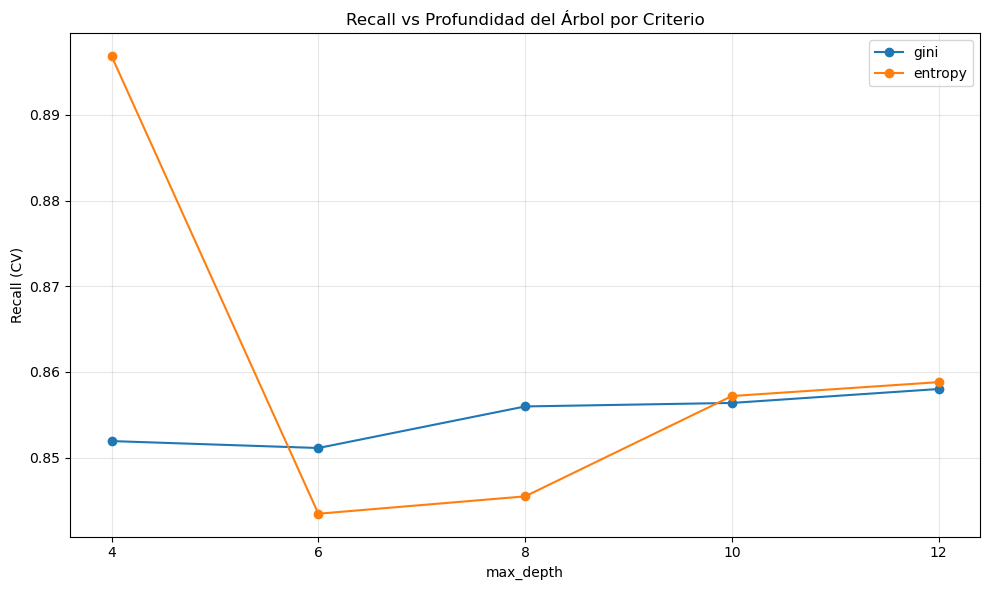

In [35]:
# === Gráfica: Recall vs max_depth por criterion ===
fig, ax = plt.subplots(figsize=(10, 6))

for criterion in ['gini', 'entropy']:
    mask = results_tree['param_classifier__criterion'] == criterion
    grouped = (results_tree[mask]
               .groupby('param_classifier__max_depth')
               ['mean_test_score'].mean())
    ax.plot(grouped.index, grouped.values, marker='o', label=criterion)

ax.set_xlabel('max_depth')
ax.set_ylabel('Recall (CV)')
ax.set_title('Recall vs Profundidad del Árbol por Criterio')
ax.set_xticks([4, 6, 8, 10, 12])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# === Importancia de variables ===
best_tree = grid_tree.best_estimator_.named_steps['classifier']

ohe_names = (preprocessing
             .named_transformers_['categoricas']
             .named_steps['encoder']
             .get_feature_names_out(cat_binarias + cat_nominal)
             .tolist())

feature_names = numericas + cat_Ordinal + ohe_names

importances = pd.Series(best_tree.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de Variables - Árbol de Decisión')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print("Top 5 variables más importantes:")
print(importances.sort_values(ascending=False).head())

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

# 10. COSAS

In [30]:
2. Aplicar la limpieza:
python# Limpiar train (X e y deben estar juntos para eliminar filas sincronizadamente)
train_limpio = limpiar_datos(
    X_train.assign(Hipertension=y_train)
)
X_train = train_limpio.drop(columns=['Hipertension'])
y_train = train_limpio['Hipertension']

# Limpiar test (misma función, misma regla)
test_limpio = limpiar_datos(
    X_test.assign(Hipertension=y_test)
)
X_test = test_limpio.drop(columns=['Hipertension'])
y_test = test_limpio['Hipertension']

print(f"\nTrain final: {X_train.shape[0]} registros")
print(f"Test final:  {X_test.shape[0]} registros")




3. Pipeline de transformación (sklearn):
pythonfrom sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definir columnas por tipo
num_features = ['Edad', 'Nivel_Stres', 'Colesterol', 
                'Duración_Sueño', 'BMI', 'Glucosa']

cat_ordinal_features = ['Actividad_Fisica']

cat_nominal_features = ['Medicación', 'Historia_Familiar', 
                        'Fumador', 'Enfermedad_Corazon']

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('ord', OrdinalEncoder(categories=[['Baja', 'Moderada', 'Alta']]), 
            cat_ordinal_features),
    ('cat', OneHotEncoder(drop='if_binary', sparse_output=False), 
            cat_nominal_features)
], remainder='drop')  # drop ignora columnas no listadas (como Ingesta_Sal)





4. Pipeline completo con modelo:
python# Para Árbol de Decisión
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=77))
])

# Para KNN
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])








5. Uso a futuro con datos nuevos:
python# Llega un paciente nuevo
nuevo_paciente = pd.DataFrame({
    'Edad': [55], 'Nivel_Stres': [7], 'Colesterol': [245],
    'Duración_Sueño': [5.5], 'BMI': [31.2], 'Glucosa': [130],
    'Actividad_Fisica': ['Baja'], 'Medicación': ['Ninguna'],
    'Historia_Familiar': ['Si'], 'Fumador': ['No'],
    'Enfermedad_Corazon': ['No'], 'Ingesta_Sal': [8.5]
})

# Paso 1: limpiar (misma función)
nuevo_limpio = limpiar_datos(nuevo_paciente)

# Paso 2: predecir (el pipeline hace todo el preprocesamiento internamente)
prediccion = pipe_tree.predict(nuevo_limpio)
print(f"Riesgo de hipertensión: {prediccion[0]}")

SyntaxError: invalid syntax (743299592.py, line 1)

In [ ]:
resumen = pd.DataFrame({
    'tipo_dtype': data.dtypes,
    'num_unicos': data.nunique(),
    'nulos': data.isnull().sum(),
    'pct_nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'min': data.min(numeric_only=True),
    'max': data.max(numeric_only=True),
    'ejemplo_valores': [data[col].dropna().unique()[:5].tolist() for col in data.columns],
    'posible_tipo': [
        'Categorica' if data[col].nunique() <= 10 
        else 'Binaria' if data[col].nunique() == 2 
        else 'Numerica' 
        for col in data.columns
    ]
})
resumen

In [ ]:
resumen = pd.DataFrame({
    'tipo_dtype': train.dtypes,
    'num_unicos': train.nunique(),
    'nulos': train.isnull().sum(),
    'pct_nulos': (train.isnull().sum() / len(train) * 100).round(2),
    'ejemplo_valores': [train[col].dropna().unique()[:5].tolist() for col in train.columns],
    'posible_tipo': [
        'Binaria' if train[col].nunique() == 2
        else 'Categórica' if train[col].nunique() <= 10
        else 'Numérica continua'
        for col in train.columns
    ]
})
resumen

## Detección de outliners:

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol',
            'Duración_Sueño', 'BMI', 'Glucosa']

for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data.boxplot(column=col, ax=ax)
    ax.set_title(col)

axes[1, 3].axis('off')
plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Colesterol: outliers extremos
print("=== Outliers extremos en Colesterol ===")
print(data[data['Colesterol'] > 500][['Colesterol']])
print(f"\nEstadísticas normales de Colesterol (sin outliers > 500):")
print(data[data['Colesterol'] <= 500]['Colesterol'].describe())

In [ ]:
# Distribución de variables numéricas
%matplotlib inline
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col)
axes[1, 3].axis('off')
plt.suptitle('Distribuciones de Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

num_features = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 
                'Duración_Sueño', 'BMI', 'Glucosa']

cat_nominal_features = ['Medicación', 'Historia_Familiar', 'Fumador', 'Enfermedad_Corazon']


cat_ordinal_features = ['Actividad_Fisica']

Tiene un orden natural (Baja < Moderada < Alta),
  por lo que se codifica como 0, 1, 2 respetando esa relación ordinal.

In [ ]:
rom sklearn.compose import ColumnTransformer 
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"] 
cat_attribs = ["ocean_proximity"] 

cat_pipeline = make_pipeline( SimpleImputer(strategy="most_frequent"), 
                             OneHotEncoder(handle_unknown="ignore")) 
preprocessing = ColumnTransformer([ ("num", num_pipeline, num_attribs), 
                                   ("cat", cat_pipeline, cat_attribs), ])

In [ ]:
Grid Search One option would be to fiddle with the hyperparameters manually, until you find a great combination of hyperparameter values. 
This would be very tedious work, and you may not have time to explore many combinations. Instead, you can use Scikit-Learn’s GridSearchCV 
class to search for you. All you need to do is tell it which hyperparameters you want it to experiment with and what values to try out, and 
it will use cross-validation to evaluate all the possible combinations of hyperparameter values. For example, the following code searches for
the best combination of hyperparameter values for the RandomForestRegressor: 

from sklearn.model_selection import GridSearchCV 
full_pipeline = Pipeline([ ("preprocessing", preprocessing),  
                      ("random_forest", RandomForestRegressor(random_state=42)), ]) 

param_grid = [ {'preprocessing__geo__n_clusters': [5, 8, 10], 'random_forest__max_features': [4, 6, 8]},
               {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, 10]}, ] 
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error') grid_search.fit(housing, housing_labels) Notice that you can refer to any hyperparameter of any estimator in a pipeline, even if this estimator is nested deep inside several pipelines and column transformers. For example, when Scikit-Learn sees "preprocessing__geo__n_clusters", it splits this string at the double underscores, then it looks for an estimator named "preprocessing" in the pipeline and finds the preprocessing ColumnTransformer. Next, it looks for a transformer named "geo" inside this ColumnTransformer and finds the 

# Pipiline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat_nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error'), 
         cat_nominal_features),
        ('cat_ordinal', OrdinalEncoder(categories=[['Baja', 'Moderada', 'Alta']]), 
         cat_ordinal_features)
    ],
    remainder='drop'
)

X_train_transformed = preprocessor.fit_transform(train)
print(f"Columnas transformadas: {X_train_transformed.shape[1]}")

ohe_names = preprocessor.named_transformers_['cat_nominal'].get_feature_names_out(cat_nominal_features).tolist()
all_feature_names = num_features + ohe_names + cat_ordinal_features
print(f"Nombres de features: {all_feature_names}")

# Árbol


In [ ]:
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=SEED))
])

param_grid_tree = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4, 6, 8, 10, 12],
    'classifier__min_samples_split': [3, 4, 5]
}

grid_tree = GridSearchCV(
    pipe_tree,
    param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid_tree.fit(X_train, y_train)

print("=== Árbol de Decisión - GridSearchCV ===")
print(f"Mejores hiperparámetros: {grid_tree.best_params_}")
print(f"Mejor accuracy (CV): {grid_tree.best_score_:.4f}")

In [ ]:
best_criterion = grid_tree.best_params_['classifier__criterion']
best_min_samples = grid_tree.best_params_['classifier__min_samples_split']

pipe_tree_rules = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion=best_criterion,
        max_depth=3,
        min_samples_split=best_min_samples,
        random_state=SEED
    ))
])
pipe_tree_rules.fit(X_train, y_train)

In [ ]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    pipe_tree_rules.named_steps['classifier'],
    feature_names=all_feature_names,
    class_names=['No Hipertensión', 'Sí Hipertensión'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('Árbol de Decisión (Profundidad = 3)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
def limpiar_datos(df):
    """
    Aplica reglas de negocio clínicas para limpiar datos.
    Reutilizable para train, test y datos nuevos a futuro.
    
    Reglas basadas en literatura médica:
    - Colesterol total > 500 mg/dL: clínicamente imposible 
      (incluso en hipercolesterolemia familiar homocigota 
       los niveles rara vez superan este umbral - NCBI/NIH)
    """
    df_clean = df.copy()
    
    # Marcar registros inválidos
    mask_invalido = df_clean['Colesterol'] > 500
    n_invalidos = mask_invalido.sum()
    
    if n_invalidos > 0:
        print(f"⚠️ {n_invalidos} registros con Colesterol > 500 mg/dL eliminados (error de captura)")
    
    df_clean = df_clean[~mask_invalido]
    
    return df_clean